In [1]:
%%capture
! pip install laspy

In [2]:
# Geospatial and mapping libraries
import geopandas as gpd

# LAS (LiDAR) file handling
import laspy
from laspy import read

# Data analysis and manipulation
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Warnings management
import warnings

In [3]:
def load_and_filter_las(file_path: str, filter_class: int = 5) -> np.ndarray:
    """
    Load a .las file and return points filtered by classification.
    """
    try:
        las = laspy.read(file_path)
        mask = las.classification == filter_class
        points = np.stack([las.x[mask], las.y[mask], las.z[mask]], axis=1)
        return points
    except Exception as e:
        print(f"Error loading and filtering file: {e}")
        return None


In [5]:
# Path to your .las file
lidar_df_1 = "data/als/plot_01.las"

# Load the point cloud with ground points filtered
point_cloud = load_and_filter_las(lidar_df_1, filter_class=5)

# Check the result
if point_cloud is not None:
    print(f"Loaded point cloud with {point_cloud.shape[0]} points.")
    print("First 5 points:\n", point_cloud[:5])
else:
    print("Failed to load the .las file.")

Loaded point cloud with 213993 points.
First 5 points:
 [[5.47126022e+05 6.45033246e+06 1.92615000e+02]
 [5.47124386e+05 6.45032342e+06 2.10831000e+02]
 [5.47123899e+05 6.45032277e+06 2.10599000e+02]
 [5.47125966e+05 6.45033108e+06 2.08661000e+02]
 [5.47125052e+05 6.45032978e+06 2.07589000e+02]]


In [8]:
from utils import read_lidar_to_df


lidar_df_1 = read_lidar_to_df("data/als/plot_01.las")
lidar_df_2 = read_lidar_to_df("data/als/plot_02.las")
lidar_df_3 = read_lidar_to_df("data/als/plot_03.las")
lidar_df_4 = read_lidar_to_df("data/als/plot_04.las")
lidar_df_5 = read_lidar_to_df("data/als/plot_05.las")
lidar_df_6 = read_lidar_to_df("data/als/plot_06.las")
lidar_df_7 = read_lidar_to_df("data/als/plot_07.las")
lidar_df_8 = read_lidar_to_df("data/als/plot_08.las")
lidar_df_9 = read_lidar_to_df("data/als/plot_09.las")
lidar_df_10 = read_lidar_to_df("data/als/plot_10.las")


print(lidar_df_1.classification.value_counts())
print(lidar_df_2.classification.value_counts())
print(lidar_df_3.classification.value_counts())
print(lidar_df_4.classification.value_counts())
print(lidar_df_5.classification.value_counts())
print(lidar_df_6.classification.value_counts())
print(lidar_df_7.classification.value_counts())
print(lidar_df_8.classification.value_counts())
print(lidar_df_9.classification.value_counts())
print(lidar_df_10.classification.value_counts())


classification
5.0    213993
Name: count, dtype: int64
classification
5.0    350098
Name: count, dtype: int64
classification
5.0    296168
Name: count, dtype: int64
classification
5.0    241722
Name: count, dtype: int64
classification
5.0    98878
Name: count, dtype: int64
classification
5.0    288921
Name: count, dtype: int64
classification
5.0    305722
Name: count, dtype: int64
classification
5.0    255654
Name: count, dtype: int64
classification
5.0    302378
Name: count, dtype: int64
classification
5.0    311011
Name: count, dtype: int64


In [19]:
def normalize_heights(lidar_df):
    """
    Normalize the z (height) values of the LiDAR data by subtracting the minimum z value.

    Parameters:
        lidar_df (pd.DataFrame): DataFrame containing LiDAR data.

    Returns:
        pd.DataFrame: DataFrame with a new 'z_normalized' column.
    """
    lidar_df['z_normalized'] = (lidar_df['z'] - lidar_df['z'].mean()) / lidar_df['z'].std()

    return lidar_df

# Normalize the height values for all datasets
lidar_dfs = [
    normalize_heights(lidar_df)
    for lidar_df in [
        lidar_df_1, lidar_df_2, lidar_df_3, lidar_df_4, lidar_df_5,
        lidar_df_6, lidar_df_7, lidar_df_8, lidar_df_9, lidar_df_10
    ]
]

In [23]:
def filter_points(lidar_df, height_threshold=0.5):
    """
    Filters out points below a given height threshold.

    Parameters:
        lidar_df (pd.DataFrame): DataFrame containing LiDAR data.
        height_threshold (float): Minimum height (z_normalized) for filtering.

    Returns:
        pd.DataFrame: Filtered DataFrame.
    """
    return lidar_df[lidar_df['z_normalized'] > height_threshold].reset_index(drop=True)

# Filter points for all datasets
filtered_lidar_dfs = [filter_points(df) for df in lidar_dfs]


In [24]:
from sklearn.model_selection import train_test_split

# Combine all filtered datasets into a single DataFrame
combined_lidar_df = pd.concat(filtered_lidar_dfs, ignore_index=True)

# Split into training and testing sets
train_df, test_df = train_test_split(combined_lidar_df, test_size=0.2, random_state=42)

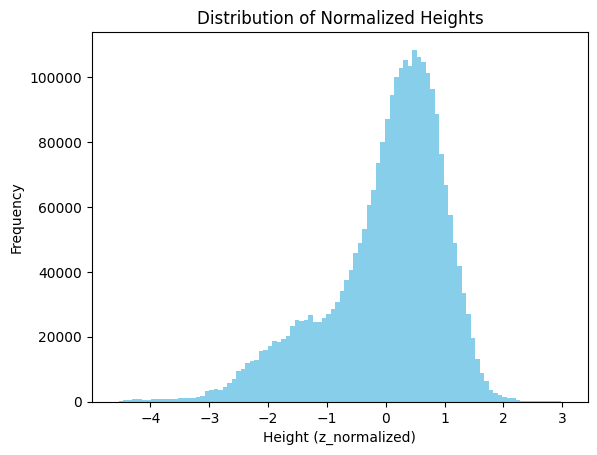

In [25]:
import matplotlib.pyplot as plt

# Combine all datasets to get a complete picture
combined_lidar_df = pd.concat(lidar_dfs, ignore_index=True)

# Plot a histogram of the normalized height
plt.hist(combined_lidar_df['z_normalized'], bins=100, color='skyblue')
plt.title("Distribution of Normalized Heights")
plt.xlabel("Height (z_normalized)")
plt.ylabel("Frequency")
plt.show()